# Notebook 4 — Conformal prediction

*Days 6-7 · turn predictions into intervals you can trust, experiment until you see why, then find where the trust runs out.*

In [2]:
# ======================================================================================
# Setup — run this first (you don't need to read it closely).
# It imports a few libraries, sets a shared plot style, and defines the helper functions used
# throughout the notebook (load_data, the plot helpers, the metric helpers, ...).  These are the
# SAME helpers in every notebook, so your results line up with your teammates'.  If a later cell
# says a helper is "not defined", you probably skipped this cell — run it, then carry on.
# ======================================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------------------------------------------------------------------
# Paths — resolved so the notebooks work whether they're run from the materials folder or
# from solutions/ .  Outputs and figures always land in the materials root.
# ----------------------------------------------------------------------------------------
def _materials_root():
    """Folder that contains data/ ; searched upward from the working directory."""
    here = os.path.abspath(os.getcwd())
    for d in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        if os.path.isdir(os.path.join(d, "data")):
            return d
    return here

ROOT = _materials_root()
DATA_DIR = os.path.join(ROOT, "data")
OUTPUTS_DIR = os.path.join(ROOT, "outputs")
FIGURES_DIR = os.path.join(ROOT, "figures")
MODELS_DIR = os.path.join(ROOT, "models")     # fitted models saved to disk (experiment tracking)
for _d in (DATA_DIR, OUTPUTS_DIR, FIGURES_DIR, MODELS_DIR):
    os.makedirs(_d, exist_ok=True)

# Module-level cache of the reconstruction basis (set by load_data; used by reconstruct_spectrum).
_RECON = {"wavelength": None, "basis": None, "is_mock": True, "Xerr": None}
_RAW_CACHE = {}   # path -> full arrays, so repeated load_data() calls don't re-read the file

# Default working-set size.  The real catalog is ~263k stars; we train on a fast deterministic
# subsample by default so in-class fits stay quick AND every notebook sees the SAME stars (which
# keeps the NB2->NB3->NB4 saved-prediction hand-off aligned).  Pass n=None to use the WHOLE
# high-quality catalog (the "does more data help?" / label-transfer-at-scale exercise).
DEFAULT_N = 30000

# Canonical label columns.  The modelling track predicts [Fe/H]; Teff & logg are explored and
# used as the axes for residual / coverage maps.  alpha/age/dist are extra "explore" labels.
LABEL_COLS = ["Teff", "logg", "FeH", "alpha", "age", "dist"]
PRETTY = {"Teff": r"$T_\mathrm{eff}$ [K]", "logg": r"$\log g$ [dex]",
          "FeH": r"[Fe/H] [dex]", "alpha": r"[$\alpha$/M] [dex]",
          "age": "age [Gyr]", "dist": "distance [pc]"}


# ========================================================================================
# Plot style
# ========================================================================================
def set_plot_style():
    """Consistent, readable matplotlib defaults.  Called once in setup."""
    plt.rcParams.update({
        "figure.figsize": (6.4, 4.4), "figure.dpi": 110, "savefig.dpi": 150,
        "savefig.bbox": "tight", "font.size": 12, "axes.titlesize": 13,
        "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.25,
        "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
        "legend.frameon": False, "legend.fontsize": 11, "lines.linewidth": 2.0,
        "scatter.edgecolors": "none", "image.cmap": "viridis",
    })

# A small colour-blind-friendly palette used across the materials for named series.
COLORS = {"linear": "#888888", "knn": "#0072B2", "rf": "#009E73",
          "nn": "#D55E00", "native": "#0072B2", "conformal": "#D55E00",
          "truth": "#222222", "accent": "#CC79A7"}


# ========================================================================================
# Data loading  (the mock generator lives here so the shipped npz and the on-the-fly
# fallback are guaranteed identical)
# ========================================================================================
_C2_NM = 1.438777e7  # second radiation constant hc/k in nm*K


def _build_basis(wave_min=336.0, wave_max=1020.0, n_wave=343, n_bp=55, n_rp=55):
    """Smooth windowed-cosine modes per band, orthonormalised.  Low modes are broad
    (continuum), high modes wiggly (fine structure).  reconstruct = B @ coeff."""
    wave = np.linspace(wave_min, wave_max, n_wave)
    cols = []
    def band(lo, hi, n_modes):
        x = (wave - lo) / (hi - lo)
        win = np.where((x >= 0) & (x <= 1), np.sin(np.clip(x, 0, 1) * np.pi) ** 0.5, 0.0)
        for j in range(n_modes):
            cols.append(np.cos(j * np.pi * np.clip(x, 0, 1)) * win)
    band(wave_min, 690.0, n_bp)
    band(630.0, wave_max, n_rp)
    Q, _ = np.linalg.qr(np.column_stack(cols))
    return wave, Q[:, :n_bp + n_rp]


def _synthesize_mock(n=50000, seed=42):
    """
    # MOCK DATA — swap for the real Zenodo loader.
    Physically-motivated synthetic stand-in for the Laroche & Speagle APOGEE x Gaia-XP
    cross-match.  Returns the same dict that the shipped npz stores.  See the build spec
    and _build/make_mock_dataset.py for the full rationale.  In one sentence: a Planck
    continuum sets Teff; Balmer lines reinforce Teff; gravity-sensitive molecular bands
    carry log g; SHALLOW metal lines (suppressed at high Teff) carry the hard, heteroscedastic
    [Fe/H]; reddening + hidden factors add a realistic irreducible (aleatoric) floor.
    """
    rng = np.random.default_rng(seed)
    wave, B = _build_basis()
    W = wave.size

    # --- labels with Kiel-diagram structure: dwarfs + giants + red clump + metal-poor halo ---
    is_giant = rng.random(n) < 0.45
    Teff = np.empty(n); logg = np.empty(n); FeH = np.empty(n)
    nd, ng = np.count_nonzero(~is_giant), np.count_nonzero(is_giant)
    Td = 4000 + 3100 * rng.beta(1.5, 2.5, nd)
    Teff[~is_giant] = Td
    logg[~is_giant] = 4.62 - 0.00013 * (Td - 4500) + rng.normal(0, 0.10, nd)
    FeH[~is_giant] = rng.normal(-0.05, 0.25, nd)
    Tg = 3800 + 1700 * rng.beta(2.0, 2.3, ng)
    Teff[is_giant] = Tg
    logg[is_giant] = 1.7 + 0.00095 * (Tg - 3800) + rng.normal(0, 0.33, ng)
    FeH[is_giant] = rng.normal(-0.28, 0.34, ng)
    clump = is_giant & (rng.random(n) < 0.33); nc = np.count_nonzero(clump)
    Teff[clump] = rng.normal(4800, 140, nc); logg[clump] = rng.normal(2.45, 0.11, nc)
    FeH[clump] = rng.normal(-0.10, 0.20, nc)
    halo = rng.random(n) < 0.06; nh = np.count_nonzero(halo)
    Teff[halo] = rng.normal(4900, 450, nh)
    logg[halo] = np.clip(rng.normal(2.2, 0.7, nh), 0.5, 3.6)
    FeH[halo] = rng.normal(-1.45, 0.45, nh)
    is_giant = is_giant | halo
    Teff = np.clip(Teff, 3500, 7600); logg = np.clip(logg, 0.3, 5.0); FeH = np.clip(FeH, -2.4, 0.55)
    alpha = np.clip(0.13 - 0.24 * FeH + rng.normal(0, 0.035, n), -0.05, 0.5)
    age = np.clip(2.0 + 6.5 * is_giant - 3.5 * FeH + rng.normal(0, 1.8, n), 0.3, 13.5)
    dist = np.exp(rng.normal(6.7, 0.9, n)) * (1.0 + 1.5 * is_giant)

    # --- forward model: labels -> flux ---
    def gauss(c, w): return np.exp(-0.5 * ((wave - c) / w) ** 2)
    x = _C2_NM / (wave[None, :] * Teff[:, None])
    flux = wave[None, :] ** -5 / np.expm1(np.clip(x, 1e-6, 700))
    flux = flux / flux.mean(axis=1, keepdims=True)
    jump = 1.0 / (1.0 + np.exp((wave - 382.0) / 6.0))
    flux *= 1.0 - (0.18 * np.clip((Teff - 5200) / 2500, 0, 1.4) * (1 + 0.15 * (4.5 - logg)))[:, None] * jump[None, :]
    balmer = sum(a * gauss(c, 9.0) for c, a in [(434., .9), (486.1, 1.1), (656.3, 1.)])
    bstr = np.clip(np.exp((Teff - 5200) / 1500), 0.15, 6.0) * (1 + 0.12 * (4.5 - logg))
    flux *= 1.0 - 0.012 * bstr[:, None] * balmer[None, :]
    g_dwarf = np.clip(logg - 3.0, 0, 2.0)[:, None]; g_giant = np.clip(3.6 - logg, 0, 3.2)[:, None]
    coolf = np.clip((5500 - Teff) / 2000.0, 0.2, 1.4)[:, None]
    grav = np.zeros((n, W))
    for c, a in [(488., 1.), (521., .9), (692., .8)]: grav += a * g_dwarf * gauss(c, 15.)[None, :]
    for c, a in [(421., .9), (793., .8), (883., 1.)]: grav += a * g_giant * gauss(c, 17.)[None, :]
    flux *= 1.0 - 0.038 * coolf * grav
    metal = sum(a * gauss(c, 11.0) for c, a in
                [(422.7, 1.), (460., .7), (517.3, 1.2), (527., .9), (589.3, 1.1),
                 (670.8, .6), (770., .6), (850., .8), (920., .5)])
    # Line depth scales with metal abundance (metal-poor stars have WEAK lines -> little [Fe/H]
    # information -> the dominant, physically-correct source of heteroscedastic [Fe/H] error).
    # Temperature only mildly suppresses lines; gravity gives luminous giants slightly weaker,
    # more variable lines (they are also the sparsest, most-extrapolated regime).
    mstr = 10.0 ** (0.55 * FeH)
    tsupp = np.clip(np.exp(-(Teff - 4500) / 4800.0), 0.6, 1.25)
    line_amp = (mstr * tsupp * np.clip(0.7 + 0.22 * logg, 0.7, 1.4))[:, None]
    flux *= 1.0 - 0.045 * line_amp * metal[None, :]
    ebv = np.abs(rng.normal(0, 0.11, n))[:, None]
    ext = (550.0 / wave) ** 1.0
    flux *= 10.0 ** (-0.4 * 1.6 * ebv * (ext / ext.mean())[None, :])
    P = np.column_stack([np.sin(f * np.pi * (wave - wave[0]) / (wave[-1] - wave[0])) for f in (1.5, 3.5, 6.5)])
    flux *= 1.0 + 0.004 * (rng.normal(0, 1, (n, 3)) @ P.T)
    gflux = np.exp(rng.normal(0.0, 0.8, n))
    snr = np.clip(58 * gflux ** 0.30 * np.exp(rng.normal(0, 0.30, n)), 20, 400)
    obs = gflux[:, None] * np.clip(flux, 1e-3, None)
    noise_std = obs.mean(axis=1, keepdims=True) / snr[:, None]        # photon-noise std (per star)
    obs = obs + rng.normal(0, 1, obs.shape) * noise_std
    X = (obs @ B).astype(np.float32)
    # per-coefficient measurement error on the RAW coefficients (the orthonormal basis preserves the
    # per-component noise std) — used by the NB3 input-Monte-Carlo stretch.
    Xerr = np.repeat(noise_std, 110, axis=1).astype(np.float32)
    return dict(X=X, Xerr=Xerr, Teff=Teff, logg=logg, FeH=FeH, alpha=alpha, age=age, dist=dist,
                snr=snr, gflux=gflux, source_id=(1_000_000_000 + np.arange(n)),
                wavelength=wave, basis=B.astype(np.float32), is_mock=True)


def load_data(path=None, n=DEFAULT_N, seed=0, verbose=True):
    """
    Load the dataset in one line:  X, y, meta = load_data()

    Parameters
    ----------
    n    : working-set size.  Returns a deterministic random subsample of `n` stars (default
           DEFAULT_N=30000) so fits are fast and every notebook sees the same stars.  Pass
           `n=None` to use the ENTIRE high-quality catalog (the scale-up exercise) — slower.
    seed : seed for the subsample (keep it fixed so the NB2->NB3->NB4 hand-off stays aligned).

    Returns
    -------
    X    : float array, shape (n, 110) — the Gaia XP coefficients (55 BP + 55 RP).
    y    : DataFrame with columns Teff, logg, FeH (+ alpha, dist) — the labels.
    meta : DataFrame with source_id, snr, gflux — per-star bookkeeping (gflux is the
           brightness scale used by normalize_by_g).
    """
    if path is None:
        for cand in ("xp_apogee_real.npz", "xp_apogee_mock.npz"):
            p = os.path.join(DATA_DIR, cand)
            if os.path.exists(p):
                path = p
                break
    key = path if path is not None else "__synth__"
    if key in _RAW_CACHE:
        data = _RAW_CACHE[key]
    elif path is not None and os.path.exists(path):
        d = np.load(path, allow_pickle=True)
        data = {k: d[k] for k in d.files}
        _RAW_CACHE[key] = data
    else:
        if verbose:
            print("No data file found — synthesising the mock dataset on the fly.")
        data = _synthesize_mock()
        _RAW_CACHE[key] = data
    is_mock = bool(data.get("is_mock", True))
    src = os.path.basename(path) if path else "synthesised mock"

    _RECON["wavelength"] = np.asarray(data["wavelength"], float)
    _RECON["basis"] = np.asarray(data["basis"], float)
    _RECON["is_mock"] = is_mock

    X_all = np.asarray(data["X"], dtype=float)
    N = X_all.shape[0]
    if n is not None and n < N:
        sel = np.sort(np.random.default_rng(seed).permutation(N)[:n])
    else:
        sel = np.arange(N)
    X = X_all[sel]
    _RECON["Xerr"] = np.asarray(data["Xerr"], float)[sel] if "Xerr" in data else None  # for input-MC (NB3)
    y = pd.DataFrame({c: np.asarray(data[c], float)[sel] for c in LABEL_COLS if c in data})
    meta = pd.DataFrame({k: np.asarray(data[k]).ravel()[sel] for k in ("source_id", "snr", "gflux") if k in data})
    if verbose:
        tag = "MOCK (synthetic)" if is_mock else "REAL (Gaia XP x APOGEE)"
        extra = f" (subsampled from {N:,}; pass n=None for all)" if len(sel) < N else ""
        print(f"Loaded {src}: {tag}  —  {X.shape[0]:,} stars{extra}, {X.shape[1]} coefficients.")
    return X, y, meta


# ========================================================================================
# Spectrum reconstruction
# ========================================================================================
def load_input_errors():
    """Per-coefficient measurement errors for the stars from the LAST `load_data()` call (same rows,
    same order, same (n, 110) shape as the `X` you just loaded) — on the RAW coefficient scale.
    For the NB3 input-Monte-Carlo stretch:  X_perturbed = X + rng.normal(0, load_input_errors()).
    Returns None if the dataset has no stored errors (call `load_data()` first)."""
    if _RECON["Xerr"] is None:
        load_data(verbose=False)
    return _RECON["Xerr"]


def reconstruct_spectrum(coeffs):
    """
    Turn a star's 110 XP coefficients into a sampled spectrum: returns (wavelength_nm, flux).
    Accepts a single (110,) vector or an (M, 110) batch.

    On the shipped data this uses the stored smooth basis (B @ coeff) — no extra packages.

    # REAL DATA: with the genuine Gaia archive continuous representation you would instead
    # reconstruct with GaiaXPy, e.g.:
    #     from gaiaxpy import calibrate
    #     sampling = np.arange(336, 1021, 2.0)              # nm
    #     spectra, sampled_wl = calibrate(source_dataframe, sampling=sampling, save_file=False)
    # The stored basis is recovered from Zenodo's wavelength-space spectra at curation time
    # (see _build/prepare_real_data.py), so this helper stays identical for mock and real.
    """
    if _RECON["basis"] is None:
        load_data(verbose=False)
    B, wave = _RECON["basis"], _RECON["wavelength"]
    coeffs = np.asarray(coeffs, float)
    flux = coeffs @ B.T
    return wave, flux


# ========================================================================================
# Preprocessing recipe:  normalize by the G-band  ->  standardize (fit on train only)
# ========================================================================================
def normalize_by_g(X, g):
    """Divide each star's coefficients by its G-band brightness scale `g` (a column of meta).
    Removes brightness/distance and keeps the spectral SHAPE — what carries the labels."""
    g = np.asarray(g, float).reshape(-1, 1)
    return np.asarray(X, float) / g


def standardize(X_train, X_other):
    """Z-score the coefficients using statistics from the TRAINING set only, then apply the
    same shift/scale to another split.  Returns (X_train_scaled, X_other_scaled).
    (Equivalent to sklearn's StandardScaler fit on train; spelled out for clarity.)"""
    mu = X_train.mean(axis=0, keepdims=True)
    sd = X_train.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return (X_train - mu) / sd, (X_other - mu) / sd


# ========================================================================================
# Splitting  (fixed seed so every student gets the same train / cal / test stars)
# ========================================================================================
def train_cal_test_split(X, y, seed=0, fracs=(0.6, 0.2, 0.2)):
    """Reproducible 60/20/20 split into train / calibration / test.
    Returns a dict with X_* arrays, y_* DataFrames, and idx_* index arrays.
    Calibration is held out for the uncertainty work in NB3/NB4."""
    X = np.asarray(X, float)
    y = y.reset_index(drop=True)
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_tr = int(fracs[0] * n); n_ca = int(fracs[1] * n)
    i_tr, i_ca, i_te = idx[:n_tr], idx[n_tr:n_tr + n_ca], idx[n_tr + n_ca:]
    return {
        "X_train": X[i_tr], "X_cal": X[i_ca], "X_test": X[i_te],
        "y_train": y.iloc[i_tr].reset_index(drop=True),
        "y_cal": y.iloc[i_ca].reset_index(drop=True),
        "y_test": y.iloc[i_te].reset_index(drop=True),
        "idx_train": i_tr, "idx_cal": i_ca, "idx_test": i_te,
    }


# ========================================================================================
# Models — the four estimators the students compare.  Defined ONCE here so NB2, NB3 and NB4
# build byte-identical models, which is what lets predictions and intervals line up across
# notebooks and across the three students.  Each is a Pipeline(StandardScaler + estimator),
# so you feed it the G-normalized coefficients and it standardizes internally (fit on train).
# ========================================================================================
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

MODEL_NAMES = {"linear": "Linear regression (baseline)", "knn": "K-nearest neighbors",
               "rf": "Random forest", "nn": "Neural network (MLP)"}

def make_model(name, **overrides):
    """Canonical Pipeline(StandardScaler + estimator) for a model name in {linear,knn,rf,nn}.
    Pass overrides to tune one knob, e.g. make_model('knn', n_neighbors=20).  The step name for
    the estimator is its lowercased class name (e.g. 'kneighborsregressor') — handy in NB3 when
    you reach inside the fitted pipeline for a model-native uncertainty."""
    if name == "linear":
        est = LinearRegression(**overrides)
    elif name == "knn":
        est = KNeighborsRegressor(**{"n_neighbors": 12, **overrides})
    elif name == "rf":
        est = RandomForestRegressor(**{"n_estimators": 150, "min_samples_leaf": 3,
                                       "random_state": 0, "n_jobs": -1, **overrides})
    elif name == "nn":
        est = MLPRegressor(**{"hidden_layer_sizes": (64, 64), "alpha": 1e-3, "max_iter": 500,
                              "early_stopping": True, "random_state": 0, **overrides})
    else:
        raise ValueError(f"unknown model '{name}' (use one of {list(MODEL_NAMES)})")
    return make_pipeline(StandardScaler(), est)


# ========================================================================================
# Metrics
# ========================================================================================
def regression_metrics(y_true, y_pred):
    """Return a dict of RMSE, MAE, bias (mean signed error), and R^2."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    err = y_pred - y_true
    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2)) or 1.0
    return {"RMSE": float(np.sqrt(np.mean(err ** 2))), "MAE": float(np.mean(np.abs(err))),
            "bias": float(np.mean(err)), "R2": float(1.0 - ss_res / ss_tot)}


# ========================================================================================
# Plots — predictions & residuals
# ========================================================================================
def plot_pred_vs_true(y_true, y_pred, title=None, ax=None, color=None, label=None, units=""):
    """Scatter of predicted vs true with the 1:1 line and an RMSE annotation."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    if ax is None:
        _, ax = plt.subplots()
    lo = min(y_true.min(), y_pred.min()); hi = max(y_true.max(), y_pred.max())
    pad = 0.04 * (hi - lo + 1e-9)
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], "--", color="0.4", lw=1.3, zorder=1)
    ax.scatter(y_true, y_pred, s=8, alpha=0.35, color=color or COLORS["rf"], label=label, zorder=2)
    m = regression_metrics(y_true, y_pred)
    ax.text(0.04, 0.96, f"RMSE = {m['RMSE']:.3g}{units}\nbias = {m['bias']:+.2g}{units}",
            transform=ax.transAxes, va="top", ha="left", fontsize=10,
            bbox=dict(boxstyle="round", fc="white", ec="0.8", alpha=0.85))
    ax.set_xlabel(f"true{(' ' + units) if units else ''}")
    ax.set_ylabel(f"predicted{(' ' + units) if units else ''}")
    ax.set_xlim(lo - pad, hi + pad); ax.set_ylim(lo - pad, hi + pad)
    ax.set_aspect("equal", "box")
    if title:
        ax.set_title(title)
    if label:
        ax.legend(loc="lower right")
    return ax


def plot_residuals(y_true, y_pred, feature=None, feature_name="value", ax=None, color=None):
    """Residuals (pred - true) vs the truth, or vs an external `feature` (e.g. Teff).
    A flat band around zero means well-behaved errors; trends/fans flag structure."""
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    resid = y_pred - y_true
    xx = np.asarray(feature, float) if feature is not None else y_true
    xlabel = feature_name if feature is not None else "true value"
    if ax is None:
        _, ax = plt.subplots()
    ax.axhline(0.0, color="0.4", ls="--", lw=1.3, zorder=1)
    ax.scatter(xx, resid, s=8, alpha=0.35, color=color or COLORS["rf"], zorder=2)
    ax.set_xlabel(xlabel); ax.set_ylabel("residual (pred − true)")
    return ax


# ========================================================================================
# Uncertainty — coverage, reliability, comparison
# ========================================================================================
def empirical_coverage(y_true, lower, upper):
    """Fraction of true values that fall inside [lower, upper]."""
    y_true = np.asarray(y_true, float)
    return float(np.mean((y_true >= np.asarray(lower, float)) & (y_true <= np.asarray(upper, float))))


def plot_reliability(y_true, lower, upper, target=None, feature=None, feature_name="bin",
                     n_bins=8, ax=None, color=None, label=None):
    """
    'Are the error bars honest, everywhere?'  Bins the points (by an external `feature` such
    as Teff if given, else by the interval centre) and plots empirical coverage per bin against
    the `target` line.  Bars sitting below the target reveal where intervals under-cover.
    """
    y_true = np.asarray(y_true, float)
    lower = np.asarray(lower, float); upper = np.asarray(upper, float)
    inside = (y_true >= lower) & (y_true <= upper)
    xx = np.asarray(feature, float) if feature is not None else 0.5 * (lower + upper)
    if ax is None:
        _, ax = plt.subplots()
    edges = np.quantile(xx, np.linspace(0, 1, n_bins + 1))
    edges[-1] += 1e-9
    centers, cov = [], []
    for i in range(n_bins):
        m = (xx >= edges[i]) & (xx < edges[i + 1])
        if m.sum() >= 5:
            centers.append(xx[m].mean()); cov.append(inside[m].mean())
    ax.plot(centers, cov, "o-", color=color or COLORS["native"], label=label)
    if target is not None:
        ax.axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
    ax.set_xlabel(feature_name if feature is not None else "interval centre")
    ax.set_ylabel("empirical coverage")
    ax.set_ylim(0, 1.02)
    if target is not None or label:
        ax.legend(loc="lower center")
    return ax


def compare_intervals(y_true, intervals, target=None, ax=None):
    """
    Compare several named interval sets.  `intervals` maps name -> (lower, upper).
    Draws two bars per method — coverage and median width — and returns a tidy summary table.
    """
    y_true = np.asarray(y_true, float)
    rows = []
    for name, (lo, hi) in intervals.items():
        rows.append({"method": name, "coverage": empirical_coverage(y_true, lo, hi),
                     "median_width": float(np.median(np.asarray(hi, float) - np.asarray(lo, float)))})
    tbl = pd.DataFrame(rows).set_index("method")
    if ax is None:
        _, ax = plt.subplots(1, 2, figsize=(9.5, 4.0))
    names = list(tbl.index)
    cols = [COLORS.get(n.split()[0].lower(), COLORS["accent"]) for n in names]
    ax[0].bar(names, tbl["coverage"], color=cols)
    if target is not None:
        ax[0].axhline(target, color="0.4", ls="--", lw=1.3, label=f"target = {target:.0%}")
        ax[0].legend()
    ax[0].set_ylabel("empirical coverage"); ax[0].set_ylim(0, 1.02); ax[0].set_title("Coverage")
    ax[1].bar(names, tbl["median_width"], color=cols)
    ax[1].set_ylabel("median interval width"); ax[1].set_title("Sharpness (narrower is better)")
    for a in ax:
        a.tick_params(axis="x", rotation=20)
    return tbl


# ========================================================================================
# Small convenience used in worked examples
# ========================================================================================
def savefig(name, fig=None):
    """Save a figure into figures/ for reuse on the poster.  Returns the path."""
    path = os.path.join(FIGURES_DIR, name)
    (fig or plt.gcf()).savefig(path)
    return path


def save_outputs(filename, **arrays):
    """Save named arrays into outputs/<filename> (the shared NB2->NB3->NB4 contract)."""
    path = os.path.join(OUTPUTS_DIR, filename)
    np.savez(path, **arrays)
    return path


def load_outputs(filename):
    """Load an outputs/ npz written by an earlier notebook; returns a dict of arrays."""
    d = np.load(os.path.join(OUTPUTS_DIR, filename), allow_pickle=True)
    return {k: d[k] for k in d.files}


# ----- Experiment tracking: save fitted models + log runs (so you can reproduce & compare) -----
def save_model(model, name):
    """Save a fitted model/pipeline to models/<name>.joblib. Returns the path.
    The point: a tuned model is an experiment result — persist it so NB3 can load the exact model
    you tuned (no silent refit), and so you can reproduce a run weeks later."""
    import joblib
    path = os.path.join(MODELS_DIR, f"{name}.joblib")
    joblib.dump(model, path)
    return path


def load_model(name):
    """Load a model previously saved with save_model(...)."""
    import joblib
    return joblib.load(os.path.join(MODELS_DIR, f"{name}.joblib"))


def log_experiment(name, params, metrics, filename=None):
    """Append one experiment run (its hyper-parameters + its metrics) to a CSV and return the full
    log as a DataFrame. This is the bare-bones version of what tools like MLflow / Weights & Biases
    do: a durable, comparable record of 'what did I try, and how did it score?'.
      params  : dict of hyper-parameters, e.g. {'n_neighbors': 12, 'weights': 'distance'}
      metrics : dict of scores, e.g. {'cv_rmse': 0.21, 'test_rmse': 0.20}
    """
    path = os.path.join(OUTPUTS_DIR, filename or f"{name}_experiments.csv")
    row = {"run": 1, **{f"param_{k}": v for k, v in params.items()}, **metrics}
    if os.path.exists(path):
        prev = pd.read_csv(path)
        row["run"] = int(prev["run"].max()) + 1 if "run" in prev else len(prev) + 1
        # Rebuild from records rather than pd.concat: a run that logs different params/metrics than
        # an earlier one would otherwise make pandas align mismatched columns into all-NA entries,
        # which raises a (noisy, harmless) FutureWarning.  Building one DataFrame from a list of
        # dicts fills the gaps with NaN silently and preserves column order.
        log = pd.DataFrame(prev.to_dict("records") + [row])
    else:
        log = pd.DataFrame([row])
    log.to_csv(path, index=False)
    return log

set_plot_style()
print('Setup complete — helpers ready.')


Setup complete — helpers ready.


## Intervals you can *trust* — and a knob you can stop guessing

On Friday (Notebook 3) you turned each prediction of a star's **[Fe/H]** — its **metallicity**, the
amount of iron-group elements it holds relative to the Sun, in **dex** (a base-10 log scale: one unit
= a factor of 10) — into a **prediction interval**: a range like "[Fe/H] is between −0.55 and −0.25"
that's *meant* to contain the true value. You sized that band by **hand-tuning a fudge factor `c`** on
the calibration set until coverage hit ~90%. Then you checked it and found "90%" wasn't honest
everywhere — it sagged for **luminous giants and metal-poor stars**.

That fudge factor worked, but it left two things unsatisfying: you *eyeballed* the knob, and the band
leaned on a Gaussian-ish ±kσ picture nobody checked.

Today we replace the guesswork with a **guarantee**. **Conformal prediction** does the *same job* as
your fudge factor — turn predictions into intervals that actually cover — but it does it
**rigorously**: a *distribution-free, finite-sample* coverage guarantee, no Gaussian assumption, and
**no knob to eyeball**. Then — and this is the real point of today — you'll **experiment** with the
mechanism until you can *see why it works*, and probe exactly where the guarantee does, and doesn't,
hold.

**The arc — this notebook runs over two afternoons (Days 6–7):**

*Day 6 (Mon) — what conformal *is*, and why it works:*

1. **The bridge** — from your NB3 fudge factor to conformal: the one big idea, in pictures and one
   formula.
2. **The worked baseline** (the linear model) — five lines of numpy, and the team's Day-6 cross-check.
3. **Experiment with the mechanism** — *dial* the guarantee, *break* it on purpose and watch it
   collapse, *shrink* the calibration set, and pit it against a Gaussian band. **This is the heart of
   Day 6.**

*Day 7 (Tue) — your model, the comparison, and where the guarantee breaks:*

4. **Conformalize *your* model** — the same five lines, your predictions.
5. **Conformal vs. your native band** — guaranteed-but-rigid vs. adaptive-but-unguaranteed.
6. **Does the guarantee hold *everywhere*?** — slice coverage across temperature, gravity, and
   metallicity. (This is the poster's headline.)
7. **Stretch goals** — CQR and Mondrian, runnable, plus weighted conformal.
8. **Save** your intervals for the poster.

One nice thing about today: **you don't train anything** (except one tiny quantile model in the
optional stretch). Conformal works entirely from the predictions you already saved — that's *why* it's
"model-agnostic."

> Today's main reference is the **[*Gentle Introduction to Conformal Prediction*
> (Angelopoulos & Bates 2021)](https://arxiv.org/abs/2107.07511)**. The "[Fe/H] is hard in the
> sparse, weak-lined corners" story comes from **[Laroche & Speagle
> 2025](https://arxiv.org/abs/2404.07316)**, the paper behind our data.


## 0 · Load what you saved earlier

Everything we need is already on disk — **we do not refit any model today.** We load:

- the **point predictions** from Notebook 2 — saved on the *calibration* split and the *test* split,
  for both the **baseline** (`linear`, the shared model everyone built) and **your model** (`MODEL`);
- the **native interval** from Notebook 3 — your model's model-matched ± band, for the §5 comparison.
  (The plain linear baseline has no internal spread to read, so it never got a native band — that's
  fine, §5 compares *your* model's two bands.)

Two splits to keep straight (recap from Notebook 2):

- **calibration set** — a chunk we *deliberately* held out, never trained on. Today it does its one
  job: it *measures* how badly the model misses, so we can size the intervals honestly. (This is
  exactly the data your NB3 fudge factor was tuned on.)
- **test set** — the untouched final exam. We only ever *report* numbers on it.

We also reload each star's **Teff** (surface temperature), **log g** (surface gravity), and **[Fe/H]**
from the *same fixed split* (`seed=0`) — for both the calibration *and* test stars, because §3 and §6
need the calibration-side labels too. The seed makes the split identical to Notebooks 2 and 3 — the
same stars, in the same order.

> If a load fails, you probably haven't run Notebooks 2 and 3 yet — do those first, or grab a TA.


In [3]:
# --- choose your model -------------------------------------------------------
MODEL    = "nn"       # <- set this to YOUR assigned model:  "knn" (A) / "rf" (B) / "nn" (C)
BASELINE = "linear"    # the shared baseline everyone cross-checks in section 2
TARGET   = 0.90        # we want 90% coverage
ALPHA    = 1.0 - TARGET # = 0.10  (alpha = the miss-rate we're willing to tolerate)

# --- a small safe loader: a clear message instead of a raw FileNotFoundError -----
def need_outputs(fname):
    path = os.path.join(OUTPUTS_DIR, fname)
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Missing outputs/{fname}.  Run Notebook 2 (predictions) and Notebook 3 "
            f"(native intervals) for model='{fname.split('_')[0]}' first — or ask a TA.")
    return load_outputs(fname)

# NB2 predictions (calibration + test) for the baseline and for your model.
pred_base  = need_outputs(f"{BASELINE}_preds.npz")
pred_model = need_outputs(f"{MODEL}_preds.npz")

# NB3 native (model-matched) intervals, for the comparison in section 5.
# (Only YOUR model has a native band — the plain linear baseline has no internal spread to read,
#  so Notebook 3 never built one for it.  That's fine: section 5 compares YOUR model's two bands.)
native_model = need_outputs(f"{MODEL}_native_intervals.npz")

# Conditioning axes from the SAME fixed split (seed=0) used in NB2/NB3 — for BOTH cal and test stars
# (we reuse the calibration-side log g / [Fe/H] in sections 3 and 6).  We normalize THEN split with
# seed=0, exactly as NB2/NB3 did, so the rows line up with the saved predictions.
X, y, meta = load_data()
Xn = normalize_by_g(X, meta["gflux"])
sp = train_cal_test_split(Xn, y, seed=0)
teff_test = sp["y_test"]["Teff"].to_numpy()    # surface temperature [K]
logg_test = sp["y_test"]["logg"].to_numpy()    # surface gravity (low = luminous giant)
feh_test  = sp["y_test"]["FeH"].to_numpy()     # metallicity (low = metal-poor)
teff_cal  = sp["y_cal"]["Teff"].to_numpy()     # same axes on the calibration stars (used in §3, §6)
logg_cal  = sp["y_cal"]["logg"].to_numpy()
feh_cal   = sp["y_cal"]["FeH"].to_numpy()

# Sanity: the saved test truths line up row-for-row with the freshly-loaded labels (same seed).
assert np.allclose(sp["y_test"]["FeH"].to_numpy(), pred_model["y_test_true"]), \
    "row-order mismatch — did NB2 split with seed=0 AFTER normalize_by_g?"

print(f"baseline = '{BASELINE}',  your model = '{MODEL}',  target coverage = {TARGET:.0%}")
print(f"calibration stars: {pred_model['y_cal_true'].size:,}    test stars: {pred_model['y_test_true'].size:,}")

Loaded xp_apogee_mock.npz: MOCK (synthetic)  —  30,000 stars (subsampled from 50,000; pass n=None for all), 110 coefficients.
baseline = 'linear',  your model = 'nn',  target coverage = 90%
calibration stars: 6,000    test stars: 6,000


*Everything we need is already saved — conformal works from predictions plus held-out truths, no retraining.*

## 1 · From your fudge factor to a *guarantee*

**What you did in Notebook 3.** You had a per-star error estimate σ, you built a band `ŷ ± c·σ`, and
you **turned the knob `c`** until the calibration coverage read ~90%. That *is* calibration by hand —
and it works! But you chose `c` by eyeballing, and the band's shape leaned on a Gaussian-ish picture.

**What conformal does.** *Exactly the same job* — size a band on held-out data so it covers — but it
hands you the right width **directly**, with a theorem attached. No knob to sweep, no Gaussian
assumption. Let's see how.

**The one big idea.** Take *any* model you already have — linear, KNN, random forest, neural net, it
doesn't matter — and use the **calibration set** (data it never trained on — *exactly* why Notebook 2
carved one out) to **measure** how badly it actually misses. Then use those measured misses to size
the intervals on new stars. You let the data tell you how big the error bars must be.

The whole recipe, in four steps and one new symbol:

- **Nonconformity score.** For each calibration star, the absolute residual

  $$s_i = \lvert\, y_i - \hat{y}_i \,\rvert$$

  — literally "how wrong was the model here," in dex. Big score = badly wrong. (Why "nonconformity"?
  A big residual means that star *didn't conform* to the model's expectation.) For regression this is
  the standard, simplest choice.

- **The calibration quantile $\hat{q}$.** Pile up the calibration scores, sort them, and take the
  value that $(1-\alpha)$ of them fall at or below — for 90%, roughly the 90th percentile of the
  absolute errors. The logic is plain: 90% of the time the model's error was $\le \hat q$, so a band
  of $\pm\hat q$ should catch the truth about 90% of the time on *new* stars too. $\hat q$ is in the
  **units of $y$** (dex of [Fe/H]) — a *half-width*, **not** a probability. **This $\hat q$ is the
  principled replacement for your hand-tuned `c·σ`.**

- **The interval.** For every test star: $[\hat{y}-\hat{q},\; \hat{y}+\hat{q}]$. One number, learned
  from held-out data, turns points into guaranteed intervals.

- **Verify.** Measure the empirical coverage on the test set and check it lands near 90%.

**Why it works — exchangeability.** The *only* assumption is that the calibration stars and a new
test star are **exchangeable** — drawn from the same pool, in no special order — so a new star's error
is statistically just one more calibration error. That ranking argument is *all* the proof needs. No
bell curve, no "trust the model" — that's why conformal is **distribution-free** (it assumes nothing
about the error distribution's *shape*) and **model-agnostic** (it doesn't care which model made the
predictions). **You'll put exchangeability to the test yourself in §3 — break it on purpose and watch
coverage fall.**

**The guarantee, stated honestly.** Under exchangeability, with $n$ calibration stars,

$$1-\alpha \;\le\; P\!\left(y_\text{test} \in [\hat y - \hat q,\, \hat y + \hat q]\right) \;\le\; 1-\alpha + \tfrac{1}{n+1}.$$

Coverage is **at least** 90%, and at most a hair above. **But this probability is *marginal*** —
averaged over *all* stars — **not** a per-star or per-region promise. (Hold that thought; it's the
whole §6 story.)

**Four traps to side-step:**

1. Conformal does **not** need Gaussian errors — only exchangeability. (You'll *show* this in §3.)
2. The 90% guarantee is **on average**, not "every star / every region."
3. You **must** use the held-out **calibration** residuals — *not* training residuals (those look
   artificially small, so you'd under-cover).
4. Conformal makes your *uncertainty honest*; it does **not** make a bad model accurate.

> The exact quantile formula and the coverage bound are in the
> **[*Gentle Introduction* (Angelopoulos & Bates)](https://arxiv.org/abs/2107.07511)**. The
> *marginal vs. conditional* distinction (§6's punchline) is the same one you met in Notebook 3.


### A tiny worked-by-hand example (the one formula students fumble)

Say your calibration set had just **9 stars**, with these absolute [Fe/H] errors (dex):

$$0.05,\; 0.08,\; 0.10,\; 0.12,\; 0.15,\; 0.18,\; 0.22,\; 0.30,\; 0.45.$$

You want 90%, so $\alpha = 0.10$. The **finite-sample rule** says: take the score at rank
$\lceil (n+1)(1-\alpha)\rceil = \lceil 10 \times 0.90\rceil = 9$ — the **9th smallest = 0.45 dex**.
So $\hat q = 0.45$, and a star predicted at [Fe/H] $= -0.30$ gets the interval $[-0.75,\,+0.15]$.

**Why the "+1" and the ceiling?** With only a handful of points, to be *safe* at 90% you must reach
up toward the *biggest* error you saw; the "+1"/ceiling is a small-sample correction that keeps the
guarantee **exact**. With thousands of calibration stars (our case) it barely moves the answer — but
get the formula right. In code we simply **sort** the calibration errors and take the **$k$-th
smallest**, with $k = \lceil (n+1)(1-\alpha)\rceil$ — exactly the rank you just computed by hand.
You'll see this in the worked code next, and you'll *watch* the "+1" start to matter when you shrink
the calibration set in §3.


## 2 · Split conformal on the baseline — the Day-6 cross-check

Now we run the full recipe on the **baseline (`linear`)** predictions, end to end, in five lines.

**This is the team's Day-6 cross-check.** All three of you run this *identical* baseline example, and
you should get the *same* $\hat q$ and the *same* marginal coverage — the split is seeded and the
linear model is deterministic, so there's nothing left to disagree about. If your numbers don't
match, something upstream differs (a stale `outputs/` file, a different data version) — reconcile it
before moving on.

The four named steps: **(1)** scores on the calibration set, **(2)** the $(1-\alpha)$ quantile
$\hat q$ *with* the rank correction, **(3)** constant-width intervals on test, **(4)** verify the
marginal coverage lands on target.


In [4]:
# Split conformal, by hand, on the BASELINE predictions (pure numpy — no sklearn, no MAPIE).
y_cal_true  = pred_base["y_cal_true"]
y_cal_pred  = pred_base["y_cal_pred"]
y_test_true = pred_base["y_test_true"]
y_test_pred = pred_base["y_test_pred"]

# We will reuse the qhat rule many times below, so wrap it once (the k-th-smallest, with the
# finite-sample +1 / ceiling correction; plain averaging/interpolation would slightly under-cover).
def conformal_qhat(scores, alpha):
    """The (1 - alpha) calibration quantile = the k-th SMALLEST nonconformity score."""
    s = np.sort(np.asarray(scores, float))
    nloc = s.size
    k = int(np.ceil((nloc + 1) * (1 - alpha)))    # the rank, 1-indexed (= 9 in the by-hand example)
    return s[min(k, nloc) - 1]                     # k-th smallest; min(k, n) clamps tiny n (see below)

# 1. Nonconformity scores on the CALIBRATION set = absolute residuals.
scores = np.abs(y_cal_true - y_cal_pred)
n = scores.size

# 2. The (1 - alpha) calibration quantile.
qhat = conformal_qhat(scores, ALPHA)

# 3. Constant-width intervals on the TEST set:  y_pred +/- qhat.
lower_base = y_test_pred - qhat
upper_base = y_test_pred + qhat

# 4. Verify MARGINAL coverage (the fraction of test truths inside the band).
cov_base = empirical_coverage(y_test_true, lower_base, upper_base)
print(f"baseline qhat              = {qhat:.3f} dex   (the half-width of EVERY interval)")
print(f"baseline marginal coverage = {cov_base:.1%}   (target = {TARGET:.0%})")
print(f"baseline median width      = {np.median(upper_base - lower_base):.3f} dex")

baseline qhat              = 0.235 dex   (the half-width of EVERY interval)
baseline marginal coverage = 90.2%   (target = 90%)
baseline median width      = 0.469 dex


*Five lines of numpy turn point predictions into intervals whose **marginal** coverage lands right on the 90% target — and $\hat q$ is just the held-out 90th-percentile absolute error. No knob, no Gaussian: this is the rigorous version of your NB3 fudge factor.*

### What just happened — and one edge case

In words: $\hat q$ is the value where "90% of the time the baseline's [Fe/H] error was no larger than
this," so a band of $\pm\hat q$ catches the truth about 90% of the time on fresh stars — and it did
(the printed coverage sits right around 90%).

**Day-6 reconciliation prompt:** compare your $\hat q$ and coverage with your teammates'. On the
baseline they should match *to the digit*. Do they?

**The clamp / edge case (you'll trigger it on purpose in §3).** If you shrank the calibration set so
small that $k = \lceil (n+1)(1-\alpha)\rceil$ exceeded $n$ — fewer than 9 stars at 90% — there would
be no "$k$-th smallest," and the guarantee formally asks for $\hat q = +\infty$, an interval covering
*everything*. The `min(k, n)` clamp falls back to the largest error you actually saw. With thousands
of calibration stars it never triggers — but it's the finite-sample correction made visible.

This baseline band is honest *on average*. Hold that thought for §6.


## 3 · Experiment with the mechanism — *why* does it work?

You've run the recipe once. Now **take it apart.** Each experiment below ships **runnable** — you
change one thing and *look*. The goal isn't more recipes; it's to *see* what the guarantee depends on,
so you trust it (and know when not to). Five quick probes:

1. **Dial the guarantee** — is the 90% a real, controllable knob?
2. **Break exchangeability** — what happens when cal and test *aren't* drawn from the same pool?
3. **Shrink the calibration set** — when does the guarantee get noisy, and why the "+1"?
4. **Distribution-free, shown** — beat a Gaussian band on the *same* residuals.
5. **See the quantile** — what is $\hat q$, really?

All five reuse the saved predictions — **nothing is retrained.**


### 3.1 · Dial the guarantee

If conformal really controls coverage, then asking for 80% should *give* ~80%, asking for 99% should
give ~99%, and the empirical coverage should track the target along the diagonal. Let's check — loop
over a few targets, recompute $\hat q$ for each, and plot empirical vs. requested.


requested   80%  ->  qhat = 0.167 dex,  empirical = 80.0%
requested   90%  ->  qhat = 0.235 dex,  empirical = 90.2%
requested   95%  ->  qhat = 0.400 dex,  empirical = 95.6%
requested   99%  ->  qhat = 0.874 dex,  empirical = 99.1%


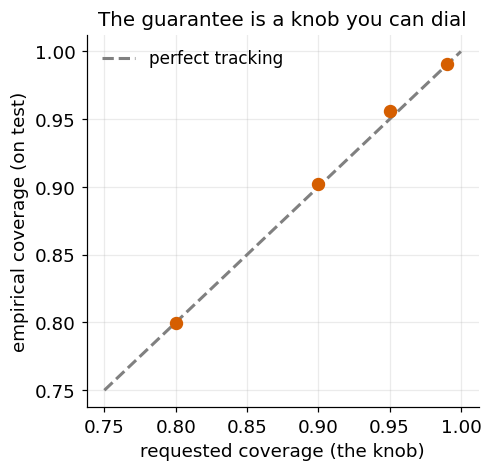

In [5]:
# Loop over a few target coverages on YOUR-or-the-baseline calibration scores and see if empirical
# coverage tracks what you asked for.  Ships runnable on the baseline; change the prediction set if you like.
yc_t, yc_p = pred_base["y_cal_true"],  pred_base["y_cal_pred"]
yt_t, yt_p = pred_base["y_test_true"], pred_base["y_test_pred"]
cal_scores = np.abs(yc_t - yc_p)

targets = [0.80, 0.90, 0.95, 0.99]        # <- your turn: add 0.50 or 0.999 and watch the point land on the line
emp = []
for T in targets:
    q   = conformal_qhat(cal_scores, 1 - T)              # recompute qhat at THIS target
    cov = empirical_coverage(yt_t, yt_p - q, yt_p + q)
    emp.append(cov)
    print(f"requested {T:5.0%}  ->  qhat = {q:.3f} dex,  empirical = {cov:5.1%}")

plt.figure(figsize=(4.6, 4.4))
plt.plot([0.75, 1.0], [0.75, 1.0], "--", color="0.5", label="perfect tracking")
plt.scatter(targets, emp, s=60, color=COLORS["conformal"], zorder=3)
plt.xlabel("requested coverage (the knob)"); plt.ylabel("empirical coverage (on test)")
plt.title("The guarantee is a knob you can dial"); plt.legend(); plt.show()

*Every point lands on the diagonal: ask for 80% and you get ~80%, ask for 99% and you get ~99%. The coverage level is a real, controllable knob — and $\hat q$ grows as you demand more.*

### 3.2 · Break exchangeability — and watch coverage collapse

The guarantee rests on **one** assumption: calibration and test stars are *exchangeable* — same pool,
no special order. What if we **violate it on purpose**? Instead of a random cal/test split, let's
calibrate on **dwarfs** (the easy, compact stars — small errors) and test on **luminous giants** (the
hard, sparse stars — big errors). Now the calibration errors are *systematically smaller* than the
test errors: cal and test no longer look alike.

Predict first: should the giant-test coverage come out near 90%, or below it? Then run it — and then
**restore the random split** and watch coverage snap back.


In [6]:
# Calibrate on DWARFS (easy), test on GIANTS (hard) -> exchangeability is broken on purpose.
yc_t, yc_p = pred_model["y_cal_true"],  pred_model["y_cal_pred"]
yt_t, yt_p = pred_model["y_test_true"], pred_model["y_test_pred"]

GDIV = 3.5                                    # <- your turn: the giant/dwarf divide in log g (try 3.0, 4.0)
cal_dwarf  = logg_cal  >= GDIV                # calibrate on dwarfs only
test_giant = logg_test <  GDIV                # ...but test on giants only

q_shift = conformal_qhat(np.abs(yc_t[cal_dwarf] - yc_p[cal_dwarf]), ALPHA)
cov_shift = empirical_coverage(yt_t[test_giant],
                               yt_p[test_giant] - q_shift, yt_p[test_giant] + q_shift)

# Now the HONEST random split (calibrate on everyone, test on everyone) for comparison.
q_rand  = conformal_qhat(np.abs(yc_t - yc_p), ALPHA)
cov_rand = empirical_coverage(yt_t, yt_p - q_rand, yt_p + q_rand)

print(f"BROKEN  (calibrate dwarfs -> test giants): qhat = {q_shift:.3f}, coverage = {cov_shift:.1%}")
print(f"RANDOM  (exchangeable split, restored):    qhat = {q_rand:.3f}, coverage = {cov_rand:.1%}  (target {TARGET:.0%})")
print()
print("Broke exchangeability -> coverage falls below target; restore it -> coverage recovers.")

BROKEN  (calibrate dwarfs -> test giants): qhat = 0.097, coverage = 74.1%
RANDOM  (exchangeable split, restored):    qhat = 0.132, coverage = 90.2%  (target 90%)

Broke exchangeability -> coverage falls below target; restore it -> coverage recovers.


*Calibrate on the easy stars, test on the hard ones, and the 90% promise **collapses** — the calibration errors were too small to size the giants' band. Put the random split back and coverage recovers. **Exchangeability is THE assumption.** §1 said a test star's error is *just one more calibration error* — but giants' errors are systematically bigger than dwarfs', so a giant test star is **not** interchangeable with a dwarf calibration pool, and the ranking argument behind the guarantee no longer applies.*

### 3.3 · Shrink the calibration set — when does the guarantee get noisy?

The guarantee is *finite-sample*, but a *tiny* calibration set makes $\hat q$ itself noisy — you're
estimating a 90th percentile from very few numbers. Subsample the calibration set to {50, 200, 1000,
all}, repeat over a few random seeds, and watch the coverage spread. (And recall §2's clamp: with
$n < (1-\alpha)/\alpha = 9$ stars at 90%, the rule literally demands "cover everything.")


In [7]:
# How few calibration stars before qhat gets noisy?  Subsample, repeat over seeds, watch the spread.
yc_t, yc_p = pred_model["y_cal_true"],  pred_model["y_cal_pred"]
yt_t, yt_p = pred_model["y_test_true"], pred_model["y_test_pred"]
full_scores = np.abs(yc_t - yc_p)

sizes = [50, 200, 1000, full_scores.size]     # <- your turn: add 9 (the alpha=0.1 edge) or 20
print(f"{'n_cal':>6} | {'mean cov':>9} {'std':>6} {'min':>6} {'max':>6}")
for nsub in sizes:
    covs = []
    for seed in range(8):                                          # a few seeds to see the spread
        idx = np.random.default_rng(seed).choice(full_scores.size, size=min(nsub, full_scores.size),
                                                 replace=False)
        q   = conformal_qhat(full_scores[idx], ALPHA)
        covs.append(empirical_coverage(yt_t, yt_p - q, yt_p + q))
    covs = np.array(covs)
    print(f"{nsub:>6} | {covs.mean():>9.3f} {covs.std():>6.3f} {covs.min():>6.3f} {covs.max():>6.3f}")
print()
print("Small n -> noisy coverage (qhat is a percentile of few numbers); large n -> rock steady.")

 n_cal |  mean cov    std    min    max
    50 |     0.912  0.031  0.869  0.944
   200 |     0.912  0.018  0.878  0.934
  1000 |     0.902  0.012  0.883  0.923
  6000 |     0.902  0.000  0.902  0.902

Small n -> noisy coverage (qhat is a percentile of few numbers); large n -> rock steady.


*With ~50 calibration stars the coverage scatters by a few percent seed-to-seed; with thousands it's rock-steady. The guarantee is *finite-sample*, but $\hat q$ is only as stable as the percentile you can estimate — and the **+1** correction is what keeps tiny-$n$ honest.*

### 3.4 · Distribution-free, shown — beat a Gaussian band

Conformal claims to be **distribution-free**: it never assumes the errors are Gaussian. Is that
actually worth anything? Let's build the *Gaussian* band you'd get from the **same** calibration
residuals — $\pm 1.645\,\sigma$, the textbook 90% band — and compare.

The catch is choosing $\sigma$. The residuals here are **heavy-tailed** (a few big misses on hard
stars), so there's *no single $\sigma$ that's right*:

- use the ordinary standard deviation, and a few outliers **inflate** $\sigma$ → the band is too
  **wide** (over-covers);
- use a *robust* spread (from the median absolute deviation, ignoring outliers), and the band is too
  **narrow** (under-covers).

Conformal sidesteps the whole dilemma: it reads the actual 90th-percentile error straight off the
sorted scores. Watch.


In [8]:
# Gaussian +/-1.645*sigma band vs conformal, from the SAME calibration residuals.
from scipy.stats import norm, kurtosis
yc_t, yc_p = pred_model["y_cal_true"],  pred_model["y_cal_pred"]
yt_t, yt_p = pred_model["y_test_true"], pred_model["y_test_pred"]
resid_cal = yc_t - yc_p                                   # signed residuals
z = norm.ppf(1 - ALPHA / 2)                               # = 1.645 for 90%

sigma_std = resid_cal.std()                               # ordinary sigma (outliers inflate it)
sigma_rob = 1.4826 * np.median(np.abs(resid_cal - np.median(resid_cal)))   # robust sigma (from MAD)
q_conf    = conformal_qhat(np.abs(resid_cal), ALPHA)      # the conformal half-width

for name, half in [("Gaussian (std sigma) ", z * sigma_std),
                   ("Gaussian (robust MAD)", z * sigma_rob),
                   ("Conformal            ", q_conf)]:
    cov = empirical_coverage(yt_t, yt_p - half, yt_p + half)
    print(f"{name}: half-width = {half:.3f} dex,  coverage = {cov:.1%}")

print()
print(f"excess kurtosis of the residuals = {kurtosis(resid_cal):.1f}   (0 = Gaussian; >0 = heavy-tailed)")
print("Neither Gaussian sigma is right: std over-covers (too wide), MAD under-covers (too narrow).")
print("Conformal reads the real 90th-percentile error and lands on target — no distribution assumed.")

Gaussian (std sigma) : half-width = 0.169 dex,  coverage = 93.9%
Gaussian (robust MAD): half-width = 0.103 dex,  coverage = 84.1%
Conformal            : half-width = 0.132 dex,  coverage = 90.2%

excess kurtosis of the residuals = 12.8   (0 = Gaussian; >0 = heavy-tailed)
Neither Gaussian sigma is right: std over-covers (too wide), MAD under-covers (too narrow).
Conformal reads the real 90th-percentile error and lands on target — no distribution assumed.


*The residuals are heavy-tailed, so the std-$\sigma$ Gaussian over-covers (wastes width) while the robust-$\sigma$ Gaussian under-covers (misses). Conformal makes **no** distribution assumption and lands on target. That's what 'distribution-free' buys you.*

### 3.5 · See the quantile — what *is* $\hat q$?

Last probe, and the most demystifying. Sort the calibration absolute errors and plot them; mark where
$\hat q$ sits. You'll see $\hat q$ is nothing exotic — it's just **the error you usually make**: 90%
of the bars are shorter than it, 10% are taller. The half-width of *every* conformal interval is that
single height.


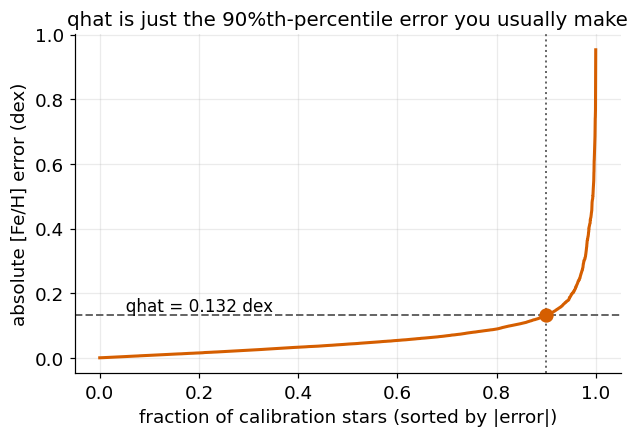

90% of calibration stars had |error| <= 0.132 dex.  That height IS the half-width.


In [9]:
# Plot the SORTED calibration |errors| with qhat marked — the whole mechanism in one picture.
yc_t, yc_p = pred_model["y_cal_true"], pred_model["y_cal_pred"]
abs_err = np.sort(np.abs(yc_t - yc_p))
q_here  = conformal_qhat(abs_err, ALPHA)
frac    = np.arange(1, abs_err.size + 1) / abs_err.size      # 0..1, the cumulative fraction

plt.figure(figsize=(6.4, 4.0))
plt.plot(frac, abs_err, color=COLORS["conformal"], lw=2)
plt.axhline(q_here, color="0.4", ls="--", lw=1.3)
plt.axvline(TARGET, color="0.4", ls=":",  lw=1.3)
plt.scatter([TARGET], [q_here], s=70, color=COLORS["conformal"], zorder=5)
plt.text(0.03, q_here, f"  qhat = {q_here:.3f} dex", va="bottom", fontsize=11)
plt.xlabel(f"fraction of calibration stars (sorted by |error|)")
plt.ylabel("absolute [Fe/H] error (dex)")
plt.title(f"qhat is just the {TARGET:.0%}th-percentile error you usually make")
plt.show()
print(f"{TARGET:.0%} of calibration stars had |error| <= {q_here:.3f} dex.  That height IS the half-width.")

*The half-width $\hat q$ is simply the error you make 90% of the time — read straight off the sorted calibration errors at the 90% mark. No formula to trust, just a ranked list of how wrong you were.*

---

# 🌅 Day 7 (Tuesday) starts here

*Yesterday (Day 6) you learned what conformal prediction is and **experimented** with the mechanism on
the shared linear baseline — dialling the guarantee, breaking exchangeability, shrinking the calibration
set. Today you turn it on **your own** model, compare it head-to-head with the native band you built in
Notebook 3, find where the guarantee quietly breaks, and save the intervals for your poster.*

*Pick up where you left off: re-run the **setup cell** and **§0 (Load)** to restore everything in memory,
then continue below. (Conformal needs no training, so this is fast.)*

---

## 4 · Conformalize *your* model

You've now poked the mechanism from every side. Time to point it at **your** model's saved predictions
(`MODEL`) — the same five-step recipe as §2, no changes. *That sameness is the entire point of
"model-agnostic."* Same target (90%), same four steps; only the predictions differ.

What to look for: marginal coverage should again land near 90%, and $\hat q$ should be **smaller** than
the baseline's if your model fits [Fe/H] more accurately (a better model misses by less, so it earns a
tighter band).


In [10]:
# Your turn: conformalize YOUR model. SAME recipe as section 2 — already runs for MODEL="knn".
# NOTE: lower_model / upper_model (and yt_true/yt_pred/yc_true/yc_pred) defined here are reused by
# sections 5-7.  If you re-run this cell, re-run those too.  To "change TARGET", edit it in the section-0
# cell and re-run from the top — not here.
yc_true = pred_model["y_cal_true"];  yc_pred = pred_model["y_cal_pred"]
yt_true = pred_model["y_test_true"]; yt_pred = pred_model["y_test_pred"]

# 1-2. scores -> the k-th-smallest qhat (reusing conformal_qhat from section 2).
scores_m = np.abs(yc_true - yc_pred)
qhat_m   = conformal_qhat(scores_m, ALPHA)

# 3. constant-width intervals on the test set.
lower_model = yt_pred - qhat_m
upper_model = yt_pred + qhat_m

# 4. check marginal coverage.
cov_model = empirical_coverage(yt_true, lower_model, upper_model)
print(f"{MODEL}: qhat = {qhat_m:.3f} dex,  marginal coverage = {cov_model:.1%}  (target {TARGET:.0%})")
print(f"{MODEL}: median interval width = {np.median(upper_model - lower_model):.3f} dex")
print(f"(the baseline's qhat from section 2 was {qhat:.3f} dex — is yours smaller?)")

# <- your turn (1): a more accurate model misses by less, so it earns a SMALLER qhat. Did yours come
#                   in below the baseline's above? Jot down why that makes sense.
# <- your turn (2): change TARGET near the top of the notebook (e.g. to 0.95) and re-run from there.
#                   Predict first — wider or narrower band? — then check.

nn: qhat = 0.132 dex,  marginal coverage = 90.2%  (target 90%)
nn: median interval width = 0.265 dex
(the baseline's qhat from section 2 was 0.235 dex — is yours smaller?)


*The same five lines conformalize **any** model — your band lands near 90% coverage too, and its half-width $\hat q$ shrinks as your model gets more accurate.*

## 5 · Conformal vs. your native band — guarantee *or* adaptivity?

In Notebook 3 you built a **native** band whose width came from *your model's own internals* (KNN's
neighbour scatter, RF's tree spread, the NN ensemble's disagreement), then **fudge-calibrated** it to
~90%. That band has a real strength: it **adapts** — it's wider where the model feels unsure (giants)
and tighter where it's confident (dwarfs).

The conformal band you just built has the opposite character: a **constant** width, but one with a
**guarantee** stapled to it — distribution-free, no knob.

So which is better? *Neither, simply* — they trade off, and the honest comparison needs **three** lenses:

- **Coverage** — is the 90% promise kept? (A band from $-\infty$ to $+\infty$ "covers" 100% and is
  useless, so coverage alone can never win.)
- **Sharpness (median width)** — narrower is better, *but only at matched coverage*.
- **Conditional coverage** — does it cover the *hard* stars (giants), not just on average?

Read them together:

- **conformal** = a **guaranteed** marginal coverage, but a **constant** width → it can't adapt, so
  it leaves a *conditional gap* (you'll see giants under-covered in §6);
- **native + fudge** = an **adaptive** width (often *better conditional* coverage) but **no
  guarantee** — it's a hand-tuned point estimate that can quietly break under distribution shift
  (exactly the §3.2 failure).

Let's measure all three.


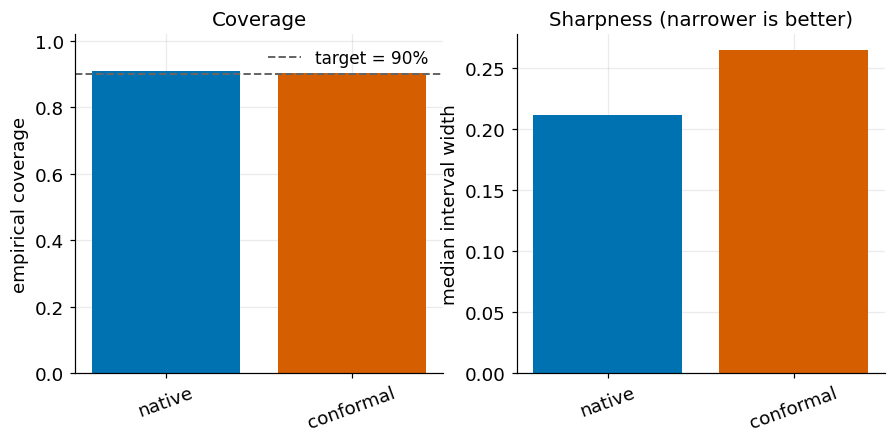

native   : marginal = 90.9%   giants = 89.8%
conformal: marginal = 90.2%   giants = 83.6%


,coverage,median_width
method,,
native,0.908667,0.211108
conformal,0.901833,0.264520


In [11]:
# Put NB3's native band next to today's conformal band for YOUR model — coverage, width, AND giants.
nat_lo, nat_hi = native_model["lower"], native_model["upper"]   # the adaptive, fudge-calibrated band from NB3

summary = compare_intervals(
    yt_true,
    {"native":    (nat_lo, nat_hi),                 # NB3 adaptive band
     "conformal": (lower_model, upper_model)},      # NB4 split-conformal band   <- your turn: plug yours in
    target=TARGET,
)
savefig(f"{MODEL}_native_vs_conformal.png")
savefig("nb4_plt1_SBI_ff_and_conformal_sharpness.png")
plt.show()

# The third lens: conditional coverage on the GIANTS (the hard stars).  Does adaptivity help there?
# Use the SAME most-luminous-third cut as section 6, where the gap is clearest (3.5 mixes in easy sub-giants).
giants = logg_test < np.quantile(logg_test, 1/3)
for name, (lo, hi) in [("native", (nat_lo, nat_hi)), ("conformal", (lower_model, upper_model))]:
    print(f"{name:9s}: marginal = {empirical_coverage(yt_true, lo, hi):.1%}   "
          f"giants = {empirical_coverage(yt_true[giants], lo[giants], hi[giants]):.1%}")
summary   # columns: coverage | median_width  (read with the giants line above)

*Read all three: both bands hit ~90% **marginally**, but the **adaptive native band covers the giants better** (it widened for them), while the **constant conformal band carries the guarantee** the native one only achieved by hand-tuning. Guarantee vs. adaptivity — that tension is what §7's CQR resolves.*

## 6 · Does the guarantee hold *everywhere*? (the poster headline)

Recall the catch from §1: the guarantee is **marginal** — right *on average*. Now the question that
matters for science: is it right *everywhere*?

**Conditional coverage** means coverage *within every slice* of the data, not just overall. We'll
slice the test stars three ways and ask, in each slice, "does the conformal band still catch 90%?"

- by **Teff** (temperature),
- by **log g** (surface gravity — *low* log g = a puffed-up **luminous giant**; *high* = a compact
  **dwarf**),
- by **[Fe/H]** (metallicity — *low* = **metal-poor**).

Why these axes? Because the physics makes [Fe/H] **harder to read in some places than others**, and
the errors there are bigger (the noise is **heteroscedastic** — its size changes across the data,
just like in Notebook 3):

- **Metal-poor stars** have only faint metal absorption lines, so the spectrum carries little [Fe/H]
  information — large, irreducible scatter.
- **Luminous giants** are the sparse, most-extrapolated corner of the training set — few neighbours,
  weak lines, the hardest regime. (This is the real Laroche & Speagle effect, baked into our data.)

The metal-poor end is the worst, but watch the **most metal-rich** bin too: it often **sags** below the
line as well, because *both* metallicity tails are sparse, under-sampled corners — the constant band is
tuned for the dense middle, not the edges.

A single constant-width conformal band, tuned to be right *on average*, then **over-covers the easy
stars and under-covers the hard ones** — even though its *marginal* number looks perfect. This is the
direct consequence of the "constant width" trade-off you saw in §5.

**Don't take our word for it — let the plot show you.** `plot_reliability(..., feature=…)` bins the
test stars into 8 equal-count bins along whichever axis you pass, and plots **measured coverage per
bin** against the dashed 90% line. Bins on the line = honest there; bins sagging below = under-cover
there. (Equal-*count* bins, so marker spacing reflects star density, not even steps; a bin with fewer
than 5 stars is dropped.)

**This is the poster's headline.** Conformal gives a *real, distribution-free* guarantee — but it's a
*marginal* one, and "right on average" hides "wrong for giants and metal-poor stars." Naming that gap,
showing it across these three axes, and pointing at the fix **is** the science. It's a feature of the
project, not a failure to hide.

> The marginal-vs-conditional distinction is in the
> **[*Gentle Introduction*](https://arxiv.org/abs/2107.07511)**; the physics of *where* [Fe/H] is
> hard is **[Laroche & Speagle 2025](https://arxiv.org/abs/2404.07316)**.


nn conformal coverage:  ALL = 90.2%   giants (log g < 3.5) = 83.7%   dwarfs (log g >= 3.5) = 96.1%


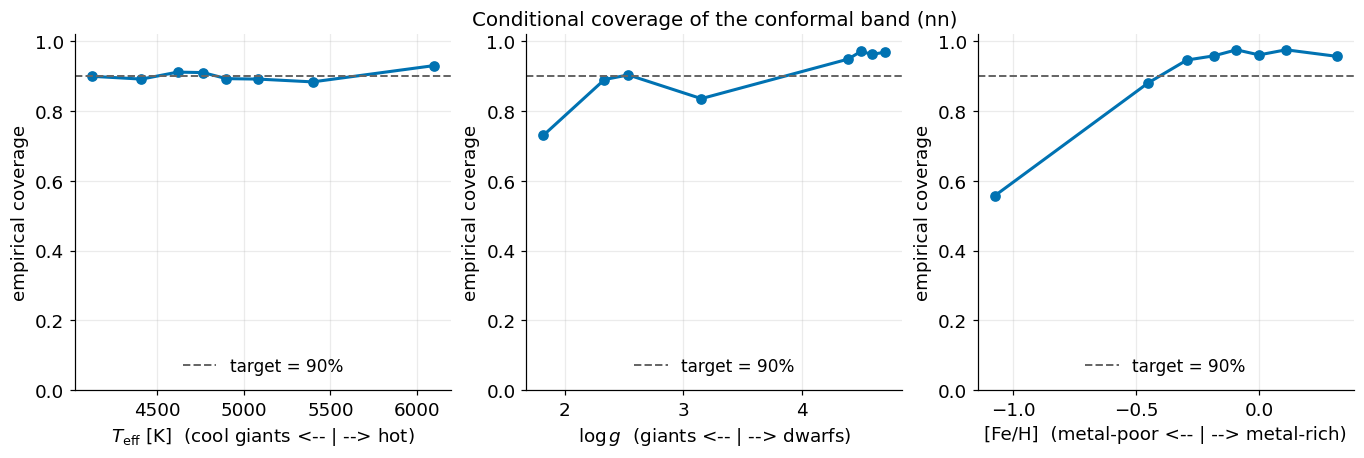

In [12]:
# A blunt first cut: split by gravity into luminous GIANTS (low log g) vs DWARFS (high log g).
GSPLIT = 3.5
giants = logg_test <  GSPLIT
dwarfs = logg_test >= GSPLIT

cov_all   = empirical_coverage(yt_true,          lower_model,          upper_model)
cov_giant = empirical_coverage(yt_true[giants],  lower_model[giants],  upper_model[giants])
cov_dwarf = empirical_coverage(yt_true[dwarfs],  lower_model[dwarfs],  upper_model[dwarfs])
print(f"{MODEL} conformal coverage:  ALL = {cov_all:.1%}   "
      f"giants (log g < {GSPLIT}) = {cov_giant:.1%}   dwarfs (log g >= {GSPLIT}) = {cov_dwarf:.1%}")

# The real diagnostic: coverage in 8 equal-count bins along THREE axes vs the 90% target.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
plot_reliability(yt_true, lower_model, upper_model, target=TARGET,
                 feature=teff_test, feature_name=r"$T_\mathrm{eff}$ [K]  (cool giants <-- | --> hot)",
                 ax=axes[0])
plot_reliability(yt_true, lower_model, upper_model, target=TARGET,
                 feature=logg_test, feature_name=r"$\log g$  (giants <-- | --> dwarfs)",
                 ax=axes[1])
plot_reliability(yt_true, lower_model, upper_model, target=TARGET,
                 feature=feh_test, feature_name=r"[Fe/H]  (metal-poor <-- | --> metal-rich)",
                 ax=axes[2])
axes[1].set_title(f"Conditional coverage of the conformal band ({MODEL})")
savefig(f"{MODEL}_conditional_coverage.png")
plt.show()

*Marginal coverage is ~90%, but sliced by gravity, metallicity, or temperature the **luminous giants** and **metal-poor** bins dip below the line — the conformal guarantee is honest on average, not everywhere.*

In [13]:
# Explore (pick one or two — there's no single right answer; each ships runnable, edit the marked knob):
#
# (1) Push the gravity split toward the luminous giants. How low does giant coverage fall?
GSPLIT_TRY = 2.5    # <- try 2.0, 2.5, 3.0  (lower = only the most luminous giants)
giants_try = logg_test < GSPLIT_TRY
print(f"(1) giants (log g < {GSPLIT_TRY}) coverage = "
      f"{empirical_coverage(yt_true[giants_try], lower_model[giants_try], upper_model[giants_try]):.1%}  "
      f"(n = {giants_try.sum()})")

# (2) Slice by [Fe/H] instead — where do the metal-poor stars land?
MP_FRAC = 0.20      # <- try 0.10, 0.20, 0.33  (smaller = only the most metal-poor stars)
mp = feh_test < np.quantile(feh_test, MP_FRAC)           # the most metal-poor fraction
print(f"(2) metal-poor (lowest {MP_FRAC:.0%}) coverage = "
      f"{empirical_coverage(yt_true[mp], lower_model[mp], upper_model[mp]):.1%}  (n = {mp.sum()})")

# (3) Combine section 3.3 with this: shrink the cal set, recompute qhat, re-check GIANT coverage.
#     Does a noisy qhat CLOSE the conditional gap, or just jitter it?  (Predict first, then look.)
N_CAL_TRY = 200     # <- try 100, 500, 2000  (smaller cal set = noisier qhat)
gi = logg_test < np.quantile(logg_test, 1/3)             # the most-luminous third (as in section 6)
full_scores = np.abs(pred_model["y_cal_true"] - pred_model["y_cal_pred"])
covs = []
for seed in range(8):                                    # a few seeds to see the spread, not one fluke
    idx = np.random.default_rng(seed).choice(full_scores.size,
                                             size=min(N_CAL_TRY, full_scores.size), replace=False)
    q_try = conformal_qhat(full_scores[idx], ALPHA)
    covs.append(empirical_coverage(yt_true[gi], yt_pred[gi] - q_try, yt_pred[gi] + q_try))
covs = np.array(covs)
print(f"(3) n_cal={N_CAL_TRY}: giant coverage mean={covs.mean():.1%}, std={covs.std():.1%}  "
      f"(the gap stays ~0.80 — a noisy qhat JITTERS it, it doesn't close it)")

(1) giants (log g < 2.5) coverage = 82.3%  (n = 1751)
(2) metal-poor (lowest 20%) coverage = 66.7%  (n = 1200)
(3) n_cal=200: giant coverage mean=85.2%, std=2.6%  (the gap stays ~0.80 — a noisy qhat JITTERS it, it doesn't close it)


## 7 · Stretch goals — closing the conditional gap

Three upgrades, all **optional** and all **runnable here**. The first two *fix* the conditional gap;
the third *fixes* the §3.2 exchangeability break.

- **CQR (Conformalized Quantile Regression)** — the adaptive-width fix that gets the **best of §5**: a
  guarantee *and* a width that adapts per star. Start from a model that predicts a *low* and a *high*
  quantile (so the raw band is already wide where the data are noisy), then conformally nudge those
  edges on the calibration set. We fit one quick quantile model on a **small slice** of the training
  stars (the only training we do today) and show it **beats constant conformal on the giants**.
- **Mondrian (group-conditional) conformal** — the numpy-only fix: run the *whole* recipe
  **separately** inside a "giant" group and a "dwarf" group, so each gets its **own** $\hat q$. The
  giants' band is then sized by *giants'* errors → coverage holds in each bin.
- **Weighted conformal** — the principled answer to §3.2's broken split: when test stars are drawn
  *differently* from calibration stars (covariate shift), **reweight** the calibration scores toward
  the test distribution to restore coverage. We demo it on a *controlled* shift where the reweighting
  is exact.

> **[CQR — Romano, Patterson & Candès 2019](https://arxiv.org/abs/1905.03222)** ·
> **[Weighted conformal under covariate shift — Tibshirani et al. 2019](https://arxiv.org/abs/1904.06019)** ·
> **[Mondrian / group-conditional (Awesome CP)](https://github.com/valeman/awesome-conformal-prediction)** ·
> **[MAPIE CQR tutorial](https://mapie.readthedocs.io/en/stable/examples_regression/4-tutorials/plot_cqr_tutorial.html)**.
> scikit-learn has no built-in conformal regressor, so the references stay external; our code is numpy
> + one sklearn quantile model only.


In [14]:
# OPTIONAL STRETCH A — CQR (Conformalized Quantile Regression).  The ONLY training we do today, on a
# small slice for speed (~15-30 s depending on your machine).  Goal: an ADAPTIVE band WITH the
# guarantee that beats constant conformal on the giants.
import warnings
from sklearn.ensemble import GradientBoostingRegressor

# Labels on the SAME seed=0 split (the X_* are already G-normalized in sp).
y_tr  = sp["y_train"]["FeH"].to_numpy()
y_ca  = sp["y_cal"]["FeH"].to_numpy()
y_te  = sp["y_test"]["FeH"].to_numpy()
X_tr, X_ca, X_te = sp["X_train"], sp["X_cal"], sp["X_test"]

# Fit a LOW-quantile and a HIGH-quantile regressor on a small random slice of the training stars.
CQR_SLICE = 3000     # <- your turn: 1000 is faster, 6000 gives sharper quantiles (and is slower)
slice_idx = np.random.default_rng(0).choice(X_tr.shape[0], size=CQR_SLICE, replace=False)
mk = lambda a: GradientBoostingRegressor(loss="quantile", alpha=a, n_estimators=100,
                                         max_depth=3, learning_rate=0.1, subsample=0.7, random_state=0)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lo_q = mk(ALPHA / 2).fit(X_tr[slice_idx], y_tr[slice_idx])       # ~5th percentile
    hi_q = mk(1 - ALPHA / 2).fit(X_tr[slice_idx], y_tr[slice_idx])   # ~95th percentile

# CQR conformity score on CALIBRATION: how far OUTSIDE the [q_lo, q_hi] band did the truth fall?
q_lo_ca, q_hi_ca = lo_q.predict(X_ca), hi_q.predict(X_ca)
E = np.maximum(q_lo_ca - y_ca, y_ca - q_hi_ca)        # >0 means outside the raw band
qc = conformal_qhat(E, ALPHA)                          # one conformal correction for BOTH edges

# Adaptive intervals on test: widen each edge by the SAME qc (the band stays adaptive in shape).
q_lo_te, q_hi_te = lo_q.predict(X_te), hi_q.predict(X_te)
cqr_lo, cqr_hi = q_lo_te - qc, q_hi_te + qc

gL = np.quantile(logg_test, 1/3); gH = np.quantile(logg_test, 2/3)
gi, dw = logg_test < gL, logg_test > gH
print(f"CQR (adaptive + guarantee): marginal = {empirical_coverage(y_te, cqr_lo, cqr_hi):.1%}   "
      f"median width = {np.median(cqr_hi - cqr_lo):.3f}")
print(f"   giants = {empirical_coverage(y_te[gi], cqr_lo[gi], cqr_hi[gi]):.1%}   "
      f"dwarfs = {empirical_coverage(y_te[dw], cqr_lo[dw], cqr_hi[dw]):.1%}")
print(f"constant conformal ({MODEL}):  marginal = {empirical_coverage(yt_true, lower_model, upper_model):.1%}   "
      f"median width = {np.median(upper_model - lower_model):.3f}")
print(f"   giants = {empirical_coverage(yt_true[gi], lower_model[gi], upper_model[gi]):.1%}   "
      f"dwarfs = {empirical_coverage(yt_true[dw], lower_model[dw], upper_model[dw]):.1%}")

CQR (adaptive + guarantee): marginal = 90.8%   median width = 0.399
   giants = 88.6%   dwarfs = 92.8%
constant conformal (nn):  marginal = 90.2%   median width = 0.265
   giants = 83.6%   dwarfs = 96.9%


*CQR keeps the **same ~90% marginal guarantee** but its width **adapts** — wider for giants, tighter for dwarfs — so the **giant coverage climbs** toward the dwarf coverage. That's the best of §5: the guarantee *and* the adaptivity, in one band.*

single-qhat conformal:  giants = 83.7%   dwarfs = 96.1%
Mondrian (per-group)  :  giants = 90.3%   dwarfs = 89.8%   (marginal = 90.0%)


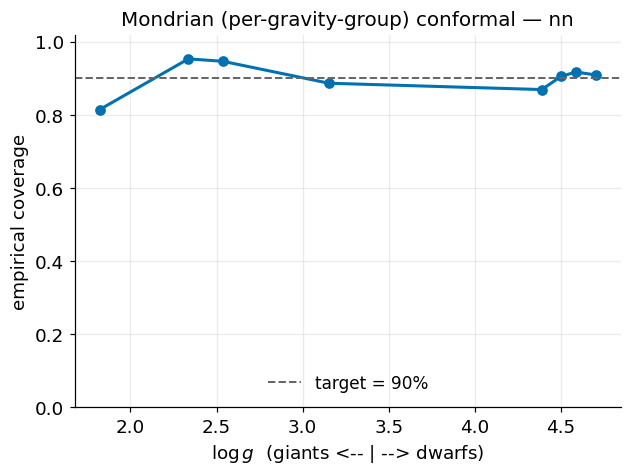

metal-poor coverage  single-qhat = 78.2%  ->  gravity-Mondrian = 80.8%  ->  [Fe/H]-Mondrian = 90.5%
Grouping by gravity barely moves metal-poor; grouping by [Fe/H] repairs it. Mondrian fixes the
axis you pick — and only that axis (a real gap when BOTH axes under-cover, as in section 6).


In [15]:
# OPTIONAL STRETCH B — Mondrian (group-conditional) conformal, numpy only.  Run the section-4 recipe
# SEPARATELY inside a GIANT group and a DWARF group, so each gets its own qhat.
GROUP_EDGE = 3.5     # the giant / dwarf divide in log g

lower_mond = np.empty_like(yt_pred)
upper_mond = np.empty_like(yt_pred)
for sel_cal, sel_test in [(logg_cal <  GROUP_EDGE, logg_test <  GROUP_EDGE),   # giants
                          (logg_cal >= GROUP_EDGE, logg_test >= GROUP_EDGE)]:  # dwarfs
    q = conformal_qhat(np.abs(yc_true[sel_cal] - yc_pred[sel_cal]), ALPHA)     # this group's own qhat
    lower_mond[sel_test] = yt_pred[sel_test] - q
    upper_mond[sel_test] = yt_pred[sel_test] + q

gi, dw = logg_test < GROUP_EDGE, logg_test >= GROUP_EDGE
print("single-qhat conformal:  "
      f"giants = {empirical_coverage(yt_true[gi], lower_model[gi], upper_model[gi]):.1%}   "
      f"dwarfs = {empirical_coverage(yt_true[dw], lower_model[dw], upper_model[dw]):.1%}")
print("Mondrian (per-group)  :  "
      f"giants = {empirical_coverage(yt_true[gi], lower_mond[gi], upper_mond[gi]):.1%}   "
      f"dwarfs = {empirical_coverage(yt_true[dw], lower_mond[dw], upper_mond[dw]):.1%}   "
      f"(marginal = {empirical_coverage(yt_true, lower_mond, upper_mond):.1%})")

ax = plot_reliability(yt_true, lower_mond, upper_mond, target=TARGET,
                      feature=logg_test, feature_name=r"$\log g$  (giants <-- | --> dwarfs)")
ax.set_title(f"Mondrian (per-gravity-group) conformal — {MODEL}")
plt.show()

# <- your turn: Mondrian only fixes the axis you GROUP on.  Above we grouped by gravity, which repairs
#    giants but leaves the section-6 METAL-POOR gap untouched.  Regroup by [Fe/H] terciles instead and
#    re-check metal-poor coverage (feh_cal / feh_test are already loaded from section 0):
fL, fH = np.quantile(feh_cal, [1/3, 2/3])                 # metal-poor / mid / metal-rich edges (cal)
lo_feh = np.empty_like(yt_pred); hi_feh = np.empty_like(yt_pred)
for c_lo, c_hi in [(-np.inf, fL), (fL, fH), (fH, np.inf)]:
    sc = (feh_cal  >= c_lo) & (feh_cal  < c_hi)
    st = (feh_test >= c_lo) & (feh_test < c_hi)
    q  = conformal_qhat(np.abs(yc_true[sc] - yc_pred[sc]), ALPHA)   # this [Fe/H] group's own qhat
    lo_feh[st] = yt_pred[st] - q; hi_feh[st] = yt_pred[st] + q
mp = feh_test < fL                                        # the metal-poor third
print(f"metal-poor coverage  single-qhat = {empirical_coverage(yt_true[mp], lower_model[mp], upper_model[mp]):.1%}"
      f"  ->  gravity-Mondrian = {empirical_coverage(yt_true[mp], lower_mond[mp], upper_mond[mp]):.1%}"
      f"  ->  [Fe/H]-Mondrian = {empirical_coverage(yt_true[mp], lo_feh[mp], hi_feh[mp]):.1%}")
print("Grouping by gravity barely moves metal-poor; grouping by [Fe/H] repairs it. Mondrian fixes the")
print("axis you pick — and only that axis (a real gap when BOTH axes under-cover, as in section 6).")

*Give the giants their **own** $\hat q$ (sized by giants' errors) and the conditional dip closes — per-group coverage equalizes toward ~90% in each bin. The trade: you fix only the groups you chose, and you need enough calibration stars per group.*

In [16]:
# OPTIONAL STRETCH C — weighted conformal: the principled fix for the section-3.2 break.
# We create a CONTROLLED covariate shift whose density ratio is KNOWN exactly, so we can reweight
# correctly.  Tilt the test set toward GIANTS by resampling test stars with weight w(logg)=exp(-beta*logg).
rng = np.random.default_rng(0)
beta = 1.2
tilt = lambda lg: np.exp(-beta * lg)                      # favors low log g (giants); the known ratio shape

p = tilt(logg_test); p = p / p.sum()
sh = rng.choice(logg_test.size, size=logg_test.size, replace=True, p=p)   # giant-tilted test sample
y_sh, yp_sh, lg_sh = yt_true[sh], yt_pred[sh], logg_test[sh]

# (a) STANDARD conformal (calibrated on the unshifted cal set) on the shifted test -> coverage falls.
q_std = conformal_qhat(np.abs(yc_true - yc_pred), ALPHA)
cov_std = empirical_coverage(y_sh, yp_sh - q_std, yp_sh + q_std)

# (b) WEIGHTED conformal: weight each calibration score by the KNOWN ratio p_test/p_cal = tilt(logg_cal),
#     then take the weighted (1-alpha) quantile of the calibration scores.
w = tilt(logg_cal); w = w / w.sum()                       # normalized calibration weights
order = np.argsort(np.abs(yc_true - yc_pred))
s_sorted = np.abs(yc_true - yc_pred)[order]
cw = np.cumsum(w[order])                                  # weighted CDF of the scores
q_w = s_sorted[min(np.searchsorted(cw, 1 - ALPHA), s_sorted.size - 1)]
cov_w = empirical_coverage(y_sh, yp_sh - q_w, yp_sh + q_w)

print(f"under a giant-tilted covariate shift (target {TARGET:.0%}):")
print(f"  standard conformal:  qhat = {q_std:.3f}, coverage = {cov_std:.1%}   <- broken (section 3.2)")
print(f"  weighted conformal:  qhat = {q_w:.3f}, coverage = {cov_w:.1%}   <- recovered")

under a giant-tilted covariate shift (target 90%):
  standard conformal:  qhat = 0.132, coverage = 79.3%   <- broken (section 3.2)
  weighted conformal:  qhat = 0.228, coverage = 89.2%   <- recovered


*Reweighting the calibration scores toward the test distribution **recovers** the coverage that the shift destroyed — the principled cure for the §3.2 break. In practice you'd *estimate* the density ratio (e.g. with a classifier); here we know it exactly, so the recovery is clean.*

## 8 · Save your conformal intervals

Save your model's conformal intervals in the **locked schema**, so the poster figures (regenerated
later from `outputs/`) can use them: `outputs/{MODEL}_conformal_intervals.npz` with keys
`y_test_true, lower, upper, target`.

These join `{MODEL}_preds.npz` (Notebook 2) and `{MODEL}_native_intervals.npz` (Notebook 3) — the full
evidence trail for the poster's results and limitations sections, with **no new notebook needed** to
make the final figures. Your two saved figures —
`figures/{MODEL}_native_vs_conformal.png` and `figures/{MODEL}_conditional_coverage.png` — are the
poster's two punchlines.


In [17]:
save_outputs(
    f"{MODEL}_conformal_intervals.npz",
    y_test_true=yt_true,
    lower=lower_model,
    upper=upper_model,
    target=TARGET,             # = 0.90, the nominal coverage we built for
)
# Reload and confirm the schema NB4's poster figures expect.
chk = load_outputs(f"{MODEL}_conformal_intervals.npz")
print(f"saved outputs/{MODEL}_conformal_intervals.npz")
print("keys:", sorted(chk.keys()),
      "| coverage:", f"{empirical_coverage(chk['y_test_true'], chk['lower'], chk['upper']):.1%}")

saved outputs/nn_conformal_intervals.npz
keys: ['lower', 'target', 'upper', 'y_test_true'] | coverage: 90.2%


*Saved in the shared schema — Notebook 2 preds → Notebook 3 native → Notebook 4 conformal, the full evidence trail for the poster.*

## Wrap-up — what to put on the poster

Three sentences of takeaway:

1. **Conformal prediction** is your NB3 fudge factor made **rigorous**: it wraps *any* model's
   predictions in intervals with a distribution-free, finite-sample **marginal** coverage guarantee,
   learned from a held-out calibration set — five lines of numpy, no Gaussian, no knob.
2. You **stress-tested** the mechanism — dialed the coverage, *broke* it by violating exchangeability,
   shrank the calibration set, and beat a Gaussian band — so the guarantee is something you
   *understand*, not just invoke.
3. **But the guarantee is *marginal*.** Sliced by gravity, metallicity, or temperature, the
   **luminous giants and metal-poor stars are under-covered** — and CQR / Mondrian / weighted conformal
   are the principled fixes. Naming that gap is your poster's headline.

**The bigger picture — label transfer at scale.** In Notebook 2's last experiment you watched accuracy
improve as you fed the model more of the ~263,000 labelled stars. That same trained pipeline is what
you would point at the **~220 million** stars that have a *Gaia* XP spectrum but **no** spectroscopic
label — estimating metallicities across the Milky Way where we otherwise have none. The conformal
intervals are what make those estimates *trustworthy at scale*; your conditional-coverage finding is
the caveat you would ship right alongside them.

**Bridge to the comms phase.** Your two saved figures (`native_vs_conformal`, `conditional_coverage`)
plus the `compare_intervals` table are the backbone of the **results** and **limitations** sections.

**One reflective prompt.** If you had to *ship* metallicities for 220 million Gaia stars tomorrow,
would you ship the single conformal band, the Mondrian per-group band, or CQR — and what would you tell
a user about the giants?

The conditional gap isn't a bug you introduced — it mirrors a real open problem in the field
(**[Laroche & Speagle 2025](https://arxiv.org/abs/2404.07316)**, the data's source paper). You've
reproduced and *named* it. That's science.
